# Nama   : Sayyidah Afifatuz Zahro
# NPM    : 25083010004
# Kelas  : Analisis Numerik (A)


# Volume Dua Lambung Katamaran — Analisis Numerik

**Soal:** hitung volume kedua lambung kapal dari gambar (tampak atas & tampak samping) dengan grid; 1 pola dash+kosong = 5+5 cm; lantai datar (tanpa keel) sehingga tampak depan berupa persegi panjang; volume *reserve buoyancy* tidak dihitung.

**Strategi penyelesaian**
1. **Kalibrasi** — deteksi garis grid pada PDF → 1 kotak = 45 cm.
2. **Digitalisasi** — ukur lebar lambung $w(x)$ dari tampak atas dan kedalaman $d(x)$ dari tampak samping, hanya di antara dua garis *reserve buoyancy*.
3. **Luas penampang** — karena tampak depan persegi panjang, $A(x)=w(x)\,d(x)$.
4. **Integrasi numerik** — $V=\int A(x)\,dx$ dengan Trapesium & Simpson 1/3, diuji konvergensinya dan dibandingkan dengan Cubic Spline.
5. **Kali 2** untuk dua lambung (hasil ukur menunjukkan kedua lambung identik).



In [2]:
# ===== 0. Setup =====
# Di Colab: upload perahu.pdf ke folder kerja (panel Files di kiri), lalu jalankan:
!apt-get -qq install poppler-utils
!pip -q install pdf2image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.integrate import simpson
from scipy.interpolate import CubicSpline
from pdf2image import convert_from_path

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

PDF_PATH = "perahu.pdf"
CELL_CM  = 45.0        # 1 kotak grid = 45 cm  (1 pola dash+kosong = 5+5 = 10 cm, 1 kotak ~ 4,5 pola)
X_A, X_B = 2.0, 18.0   # batas hitung (dalam kotak): garis reserve buoyancy buritan & haluan
STEP     = 0.125       # jarak antar titik ukur (kotak)

Selecting previously unselected package poppler-utils.
(Reading database ... 122815 files and directories currently installed.)
Preparing to unpack .../poppler-utils_24.02.0-1ubuntu9.9_amd64.deb ...
Unpacking poppler-utils (24.02.0-1ubuntu9.9) ...
Setting up poppler-utils (24.02.0-1ubuntu9.9) ...
Processing triggers for man-db (2.12.0-4build2) ...


## 1. Kalibrasi skala
Garis grid hijau dideteksi otomatis. Jarak antar-garis (≈71,5 piksel pada 200 dpi) = 1 kotak = **45 cm**.

In [7]:
# ===== 1. Muat gambar & kalibrasi grid =====
page = np.array(convert_from_path(PDF_PATH, dpi=200)[0].convert("RGB")).astype(int)
R, G, B = page[..., 0], page[..., 1], page[..., 2]
green = (G - R > 40) & (G - B > 40)                                  # piksel garis grid (hijau)
dark  = ((R + G + B) / 3 < 200) & ~green & (abs(R - G) < 35) & (abs(G - B) < 35)   # piksel garis lambung (abu/hitam)

def peaks(a, th):
    idx = np.where(a > th)[0]; out = []; s = p = idx[0]
    for i in idx[1:]:
        if i - p > 3: out.append((s + p) / 2); s = i
        p = i
    out.append((s + p) / 2); return np.array(out)

gx = peaks(green.sum(0), green.sum(0).max() * 0.4)   # posisi garis grid vertikal (px)
S  = np.median(np.diff(gx))                          # ukuran 1 kotak dalam piksel
X0 = gx[0]                                           # garis grid paling kiri = x = 0
Y0 = peaks(green.sum(1), green.sum(1).max() * 0.4)[0]
print(f"Jumlah garis grid vertikal terdeteksi : {len(gx)}")
print(f"Ukuran 1 kotak di gambar              : {S:.2f} piksel  (= {CELL_CM:.0f} cm di dunia nyata)")
print(f"Skala                                 : 1 piksel = {CELL_CM/S:.3f} cm")

Jumlah garis grid vertikal terdeteksi : 21
Ukuran 1 kotak di gambar              : 71.50 piksel  (= 45 cm di dunia nyata)
Skala                                 : 1 piksel = 0.629 cm


## 2. Digitalisasi lebar dan kedalaman
Lambung simetris terhadap garis tengahnya, jadi lebar = 2 × jarak sisi luar ke garis tengah. Titik yang tertutup balok melintang atau tulisan dibuang lalu diganti nilai lambung kembarnya/interpolasi. Kedalaman $d$ = jarak vertikal dari garis geladak ke dasar lambung pada tampak samping.

In [8]:
# ===== 2. Digitalisasi: ukur lebar w(x) (tampak atas) dan kedalaman d(x) (tampak samping) =====
def first_dark(px, y0, y1):
    ys = np.where(dark[y0:y1, px])[0]; return ys[0] + y0 if len(ys) else np.nan
def last_dark(px, y0, y1):
    ys = np.where(dark[y0:y1, px])[0]; return ys[-1] + y0 if len(ys) else np.nan
col = lambda xc: int(round(X0 + xc * S))

# garis tengah (sumbu simetri) tiap lambung, diukur di x = 8 kotak (bagian lurus, bersih)
c8 = col(8)
CY1 = (first_dark(c8, 125, 330) + last_dark(c8, 125, 330)) / 2     # lambung 1 (atas)
CY2 = (first_dark(c8, 640, 840) + last_dark(c8, 640, 840)) / 2     # lambung 2 (bawah)
# garis geladak pada tampak samping (diukur di bagian haluan yang polos)
DECK = np.median([first_dark(col(x), 950, 1200) for x in np.arange(16, 17.5, 0.25)])

xs = np.arange(X_A, X_B + 1e-9, STEP)
w1 = np.zeros_like(xs); w2 = np.zeros_like(xs); d = np.zeros_like(xs)
beam1 = np.zeros(len(xs), bool); beam2 = np.zeros(len(xs), bool)
for i, xc in enumerate(xs):
    px = col(xc)
    w1[i] = 2 * (CY1 - first_dark(px, 125, int(CY1))) / S           # setengah-lebar atas x2 (lambung simetris)
    w2[i] = 2 * (last_dark(px, int(CY2), 840) - CY2) / S
    d[i]  = (last_dark(px, 1100, 1175) - DECK) / S
    beam1[i] = dark[124:131, px - 6:px + 7].any()                   # kena balok melintang/label -> tandai
    beam2[i] = dark[810:817, px - 6:px + 7].any()

# buang titik yang terganggu balok/label, ganti dengan nilai lambung kembar atau interpolasi
bad  = np.abs(w1 - w2) > 0.12
bad1, bad2 = beam1 | bad, beam2 | bad
w1c = np.where(bad1 & ~bad2, w2, w1); w2c = np.where(bad2 & ~bad1, w1, w2)
both = bad1 & bad2
w1c[both] = np.interp(xs[both], xs[~both], w1[~both]); w2c[both] = np.interp(xs[both], xs[~both], w2[~both])
w1, w2 = w1c, w2c

print(f"Pusat lambung 1 : y = {CY1:.1f} px | Pusat lambung 2 : y = {CY2:.1f} px | Garis geladak : y = {DECK:.1f} px")
print(f"Jarak antar pusat lambung = {(CY2-CY1)/S:.2f} kotak = {(CY2-CY1)/S*CELL_CM/100:.2f} m")
print(f"Titik ukur: {len(xs)} titik, dari x={X_A} s/d x={X_B} kotak ({(X_B-X_A)*CELL_CM/100:.1f} m)")
print(f"Beda maksimum lebar lambung 1 vs 2 : {np.abs(w1-w2).max():.3f} kotak -> kedua lambung identik")

Pusat lambung 1 : y = 211.5 px | Pusat lambung 2 : y = 727.5 px | Garis geladak : y = 972.0 px
Jarak antar pusat lambung = 7.22 kotak = 3.25 m
Titik ukur: 129 titik, dari x=2.0 s/d x=18.0 kotak (7.2 m)
Beda maksimum lebar lambung 1 vs 2 : 0.028 kotak -> kedua lambung identik


## 3. Bukti visual: bagian yang diukur dan dihitung
Area biru/oranye adalah bagian lambung yang diintegralkan; area abu-abu (*reserve buoyancy*) tidak dihitung. Garis merah adalah potongan tiap 1 kotak.

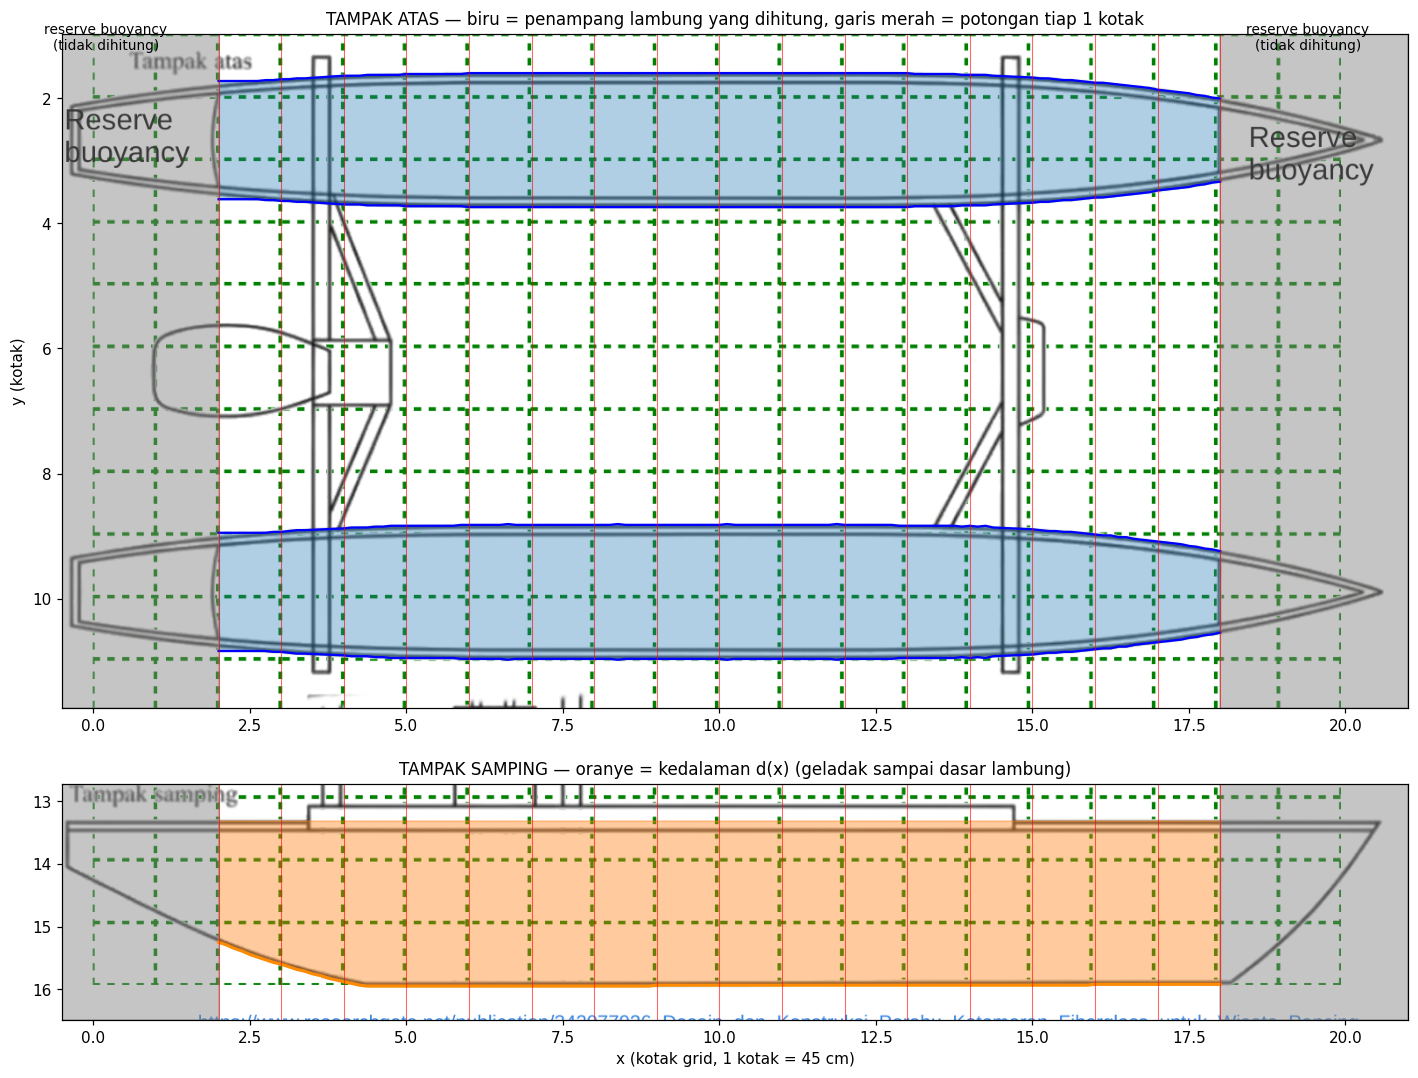

In [9]:
# ===== 3. Visual: apa yang diukur & dihitung (di atas gambar asli) =====
H, W = page.shape[:2]
def cell_extent(y0, y1): return [(0 - X0) / S, (W - X0) / S, (y1 - Y0) / S, (y0 - Y0) / S]
yc = lambda py: (py - Y0) / S

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 10), gridspec_kw={"height_ratios": [3.2, 1.2]})
# --- tampak atas ---
a1.imshow(page[90:860].astype(np.uint8), extent=cell_extent(90, 860))
for ctr, w in [(CY1, w1), (CY2, w2)]:
    a1.fill_between(xs, yc(ctr) - w / 2, yc(ctr) + w / 2, color="tab:blue", alpha=.35)
    a1.plot(xs, yc(ctr) - w / 2, "b-", lw=1.5); a1.plot(xs, yc(ctr) + w / 2, "b-", lw=1.5)
for x in np.arange(X_A, X_B + .1, 1):
    a1.axvline(x, color="red", lw=.7, alpha=.6)
for lo, hi in [(-1, X_A), (X_B, 21)]:
    a1.axvspan(lo, hi, color="gray", alpha=.45)
a1.text(0.2, yc(CY1) - 1.45, "reserve buoyancy\n(tidak dihitung)", color="k", fontsize=9, ha="center")
a1.text(19.4, yc(CY1) - 1.45, "reserve buoyancy\n(tidak dihitung)", color="k", fontsize=9, ha="center")
a1.set_xlim(-0.5, 21); a1.set_title("TAMPAK ATAS — biru = penampang lambung yang dihitung, garis merah = potongan tiap 1 kotak", fontsize=11)
a1.set_ylabel("y (kotak)")
# --- tampak samping ---
a2.imshow(page[930:1200].astype(np.uint8), extent=cell_extent(930, 1200))
bottom = DECK + d * S
a2.fill_between(xs, yc(DECK), yc(bottom), color="tab:orange", alpha=.4)
a2.plot(xs, yc(bottom), color="darkorange", lw=2)
for x in np.arange(X_A, X_B + .1, 1):
    a2.axvline(x, color="red", lw=.7, alpha=.6)
for lo, hi in [(-1, X_A), (X_B, 21)]:
    a2.axvspan(lo, hi, color="gray", alpha=.45)
a2.set_xlim(-0.5, 21); a2.set_title("TAMPAK SAMPING — oranye = kedalaman d(x) (geladak sampai dasar lambung)", fontsize=11)
a2.set_xlabel("x (kotak grid, 1 kotak = 45 cm)")
plt.tight_layout(); plt.show()

## 4. Profil lebar, kedalaman, dan luas penampang

Karena lantai datar (tanpa keel), potongan melintang lambung di setiap posisi $x$ adalah **persegi panjang**, sehingga

$$A(x) = w(x)\cdot d(x)\qquad\Longrightarrow\qquad V=\int_{x_a}^{x_b} A(x)\,dx$$

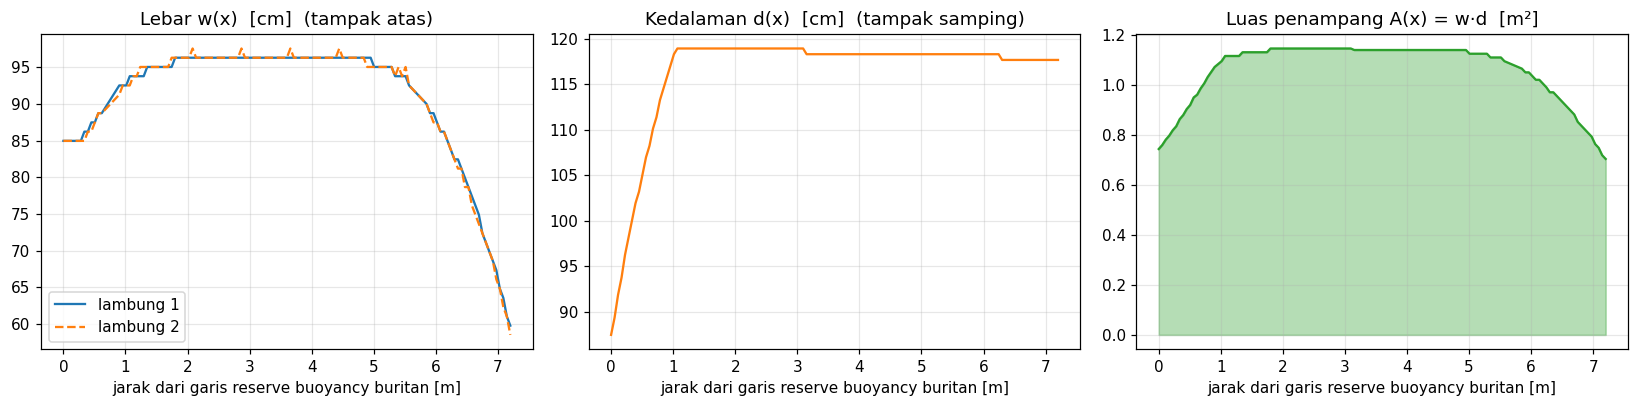

In [10]:
# ===== 4. Profil w(x), d(x), A(x) =====
cm = CELL_CM
A1 = (w1 * cm) * (d * cm) / 1e4        # m^2
A2 = (w2 * cm) * (d * cm) / 1e4
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot((xs-X_A)*cm/100, w1*cm, label="lambung 1"); ax[0].plot((xs-X_A)*cm/100, w2*cm, "--", label="lambung 2")
ax[0].set_title("Lebar w(x)  [cm]  (tampak atas)"); ax[0].legend()
ax[1].plot((xs-X_A)*cm/100, d*cm, color="tab:orange"); ax[1].set_title("Kedalaman d(x)  [cm]  (tampak samping)")
ax[2].fill_between((xs-X_A)*cm/100, A1, alpha=.35, color="tab:green"); ax[2].plot((xs-X_A)*cm/100, A1, color="tab:green")
ax[2].set_title("Luas penampang A(x) = w·d  [m²]")
for a in ax: a.set_xlabel("jarak dari garis reserve buoyancy buritan [m]"); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4b. Potongan melintang di beberapa posisi

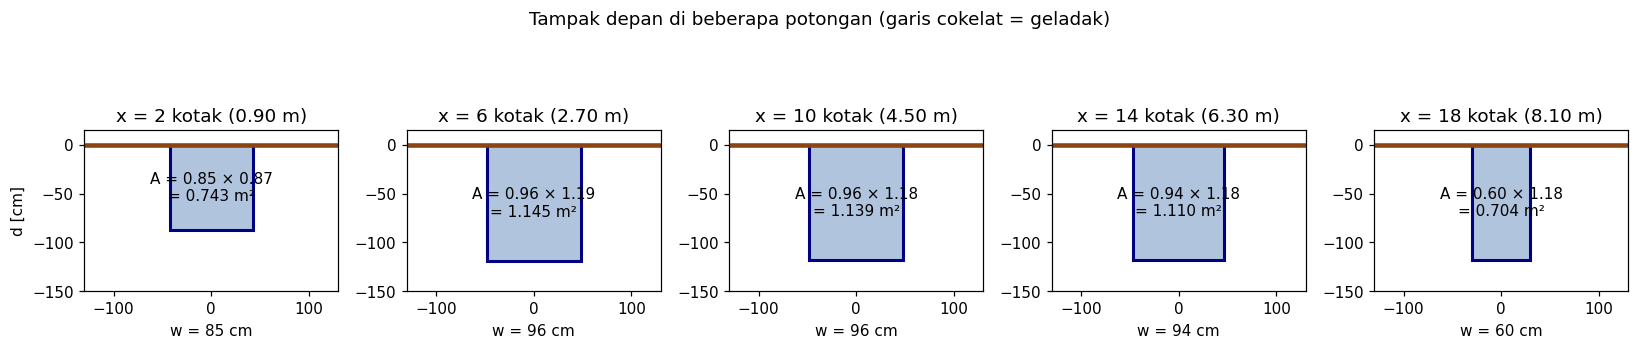

In [11]:
# ===== 5. Tampak depan: potongan melintang = persegi panjang =====
fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
for a, xc in zip(ax, [2, 6, 10, 14, 18]):
    i = int(np.argmin(np.abs(xs - xc)))
    wcm, dcm = w1[i] * cm, d[i] * cm
    a.add_patch(Rectangle((-wcm / 2, -dcm), wcm, dcm, fc="lightsteelblue", ec="navy", lw=2))
    a.text(0, -dcm / 2, f"A = {wcm/100:.2f} × {dcm/100:.2f}\n= {wcm*dcm/1e4:.3f} m²", ha="center", va="center")
    a.set_xlim(-130, 130); a.set_ylim(-150, 15); a.set_aspect("equal")
    a.axhline(0, color="saddlebrown", lw=3); a.set_title(f"x = {xc} kotak ({xc*cm/100:.2f} m)")
    a.set_xlabel(f"w = {wcm:.0f} cm"); a.set_ylabel("d [cm]" if xc == 2 else "")
plt.suptitle("Tampak depan di beberapa potongan (garis cokelat = geladak)", y=1.02); plt.tight_layout(); plt.show()

## 5. Pengerjaan integrasi numerik (satu lambung)

**Aturan Trapesium** (galat $O(h^2)$):
$$V\approx \frac{h}{2}\Big[A_0+2\sum_{i=1}^{n-1}A_i + A_n\Big]$$

**Aturan Simpson 1/3** (galat $O(h^4)$, $n$ harus genap):
$$V\approx \frac{h}{3}\Big[A_0+4\sum_{\text{ganjil}}A_i+2\sum_{\text{genap}}A_i+A_n\Big]$$

Pertama dikerjakan dengan $h = 1$ kotak = 0,45 m (16 pias) supaya bisa ditelusuri baris demi baris.

In [12]:
# ===== 6. Tabel perhitungan manual: h = 1 kotak (16 pias) =====
h = 1.0 * cm / 100                         # m
idx = np.arange(0, len(xs), int(round(1.0 / STEP)))
xi, wi, di = xs[idx], w1[idx] * cm / 100, d[idx] * cm / 100
Ai = wi * di
n = len(xi) - 1
coef = np.array([1] + [4 if k % 2 else 2 for k in range(1, n)] + [1])
print(f"{'i':>2} {'x (m)':>7} {'w (m)':>7} {'d (m)':>7} {'A=w·d (m²)':>11} {'koef Simpson':>13} {'koef×A':>9}")
for k in range(n + 1):
    print(f"{k:>2} {(xi[k]-X_A)*cm/100:>7.2f} {wi[k]:>7.3f} {di[k]:>7.3f} {Ai[k]:>11.4f} {coef[k]:>13d} {coef[k]*Ai[k]:>9.4f}")
V_trap1 = h / 2 * (Ai[0] + 2 * Ai[1:-1].sum() + Ai[-1])
V_simp1 = h / 3 * (coef * Ai).sum()
print(f"\nΣ(koef×A)            = {(coef*Ai).sum():.4f}")
print(f"V Simpson  = (h/3)·Σ = ({h:.2f}/3)·{(coef*Ai).sum():.4f} = {V_simp1:.4f} m³")
print(f"V Trapesium (h=1 kotak)                = {V_trap1:.4f} m³")

 i   x (m)   w (m)   d (m)  A=w·d (m²)  koef Simpson    koef×A
 0    0.00   0.850   0.875      0.7433             1    0.7433
 1    0.45   0.875   1.032      0.9030             4    3.6119
 2    0.90   0.925   1.158      1.0714             2    2.1428
 3    1.35   0.950   1.190      1.1305             4    4.5218
 4    1.80   0.963   1.190      1.1454             2    2.2908
 5    2.25   0.963   1.190      1.1454             4    4.5817
 6    2.70   0.963   1.190      1.1454             2    2.2908
 7    3.15   0.963   1.183      1.1394             4    4.5575
 8    3.60   0.963   1.183      1.1394             2    2.2787
 9    4.05   0.963   1.183      1.1394             4    4.5575
10    4.50   0.963   1.183      1.1394             2    2.2787
11    4.95   0.963   1.183      1.1394             4    4.5575
12    5.40   0.938   1.183      1.1096             2    2.2192
13    5.85   0.900   1.183      1.0649             4    4.2596
14    6.30   0.824   1.177      0.9703             2   

 h (kotak)  h (cm)  pias  Trapesium (m³)  Simpson (m³)  selisih Simpson vs ref
         2    90.0     8          7.5999        7.6625                +0.02209
         1    45.0    16          7.6311        7.6415                +0.00106
       0.5    22.5    32          7.6395        7.6423                +0.00188
      0.25    11.2    64          7.6442        7.6458                +0.00536
     0.125     5.6   128          7.6414        7.6404                +0.00000

Pembanding Cubic Spline (semua titik) = 7.6414 m³


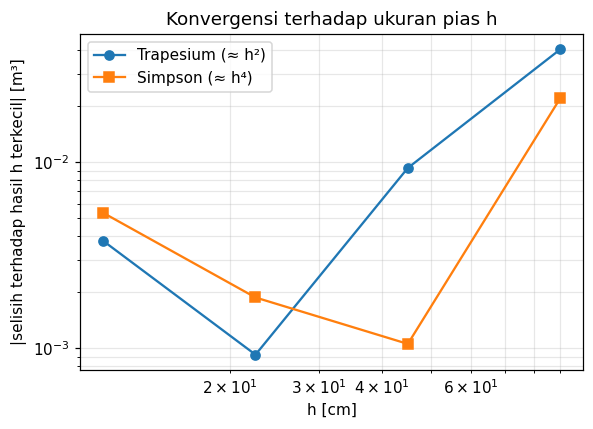

In [13]:
# ===== 7. Uji konvergensi: perkecil h, lihat hasil stabil =====
def V_of(Aprof, step_cells, method):
    k = int(round(step_cells / STEP)); a = Aprof[::k]; hh = step_cells * cm / 100
    if method == "trap": return hh * (a.sum() - 0.5 * (a[0] + a[-1]))
    return simpson(a, dx=hh)
Afull = A1
V_ref = V_of(Afull, STEP, "simp")                    # estimasi terbaik (h terkecil)
print(f"{'h (kotak)':>10} {'h (cm)':>7} {'pias':>5} {'Trapesium (m³)':>15} {'Simpson (m³)':>13} {'selisih Simpson vs ref':>23}")
hs = [2, 1, 0.5, 0.25, 0.125]
errT, errS = [], []
for hh in hs:
    vt, vs = V_of(Afull, hh, "trap"), V_of(Afull, hh, "simp")
    errT.append(abs(vt - V_ref)); errS.append(abs(vs - V_ref))
    print(f"{hh:>10} {hh*cm:>7.1f} {int((X_B-X_A)/hh):>5} {vt:>15.4f} {vs:>13.4f} {vs-V_ref:>+23.5f}")
spl = CubicSpline(xs * cm / 100, Afull).integrate(xs[0] * cm / 100, xs[-1] * cm / 100)
print(f"\nPembanding Cubic Spline (semua titik) = {spl:.4f} m³")

plt.figure(figsize=(5.5, 4))
plt.loglog(np.array(hs[:-1]) * cm, errT[:-1], "o-", label="Trapesium (≈ h²)")
plt.loglog(np.array(hs[:-1]) * cm, np.maximum(errS[:-1], 1e-6), "s-", label="Simpson (≈ h⁴)")
plt.xlabel("h [cm]"); plt.ylabel("|selisih terhadap hasil h terkecil| [m³]"); plt.grid(alpha=.3, which="both"); plt.legend()
plt.title("Konvergensi terhadap ukuran pias h"); plt.tight_layout(); plt.show()

## 6. Hasil akhir kedua lambung

In [14]:
# ===== 8. Hasil akhir =====
V1 = V_of(A1, STEP, "simp"); V2 = V_of(A2, STEP, "simp")
Vt = V1 + V2
rho = 1025.0   # kg/m3 air laut
print("=" * 58)
print(f" Volume lambung 1 (Simpson)   : {V1:8.3f} m³  = {V1*1000:9.0f} liter")
print(f" Volume lambung 2 (Simpson)   : {V2:8.3f} m³  = {V2*1000:9.0f} liter")
print(f" VOLUME TOTAL KEDUA LAMBUNG   : {Vt:8.3f} m³  = {Vt*1000:9.0f} liter")
print("=" * 58)
L = (X_B - X_A) * cm / 100
print(f"\nPanjang bagian yang dihitung : {L:.2f} m")
print(f"Lebar rata-rata              : {np.mean(w1)*cm/100:.2f} m   | Kedalaman rata-rata: {np.mean(d)*cm/100:.2f} m")
print(f"Koefisien prismatik penuh    : V/(L·wmax·dmax) = {V1/(L*np.max(w1)*cm/100*np.max(d)*cm/100):.3f}")
print(f"Gaya apung maksimum (terbenam penuh, air laut): {rho*Vt/1000:.1f} ton  ≈ {rho*9.81*Vt/1000:.0f} kN")
print("\nSensitivitas terhadap skala (V ∝ skala³):")
for s in [40, 43, 45, 50]:
    print(f"   1 kotak = {s} cm -> total {Vt*(s/CELL_CM)**3:7.3f} m³")

 Volume lambung 1 (Simpson)   :    7.640 m³  =      7640 liter
 Volume lambung 2 (Simpson)   :    7.636 m³  =      7636 liter
 VOLUME TOTAL KEDUA LAMBUNG   :   15.276 m³  =     15276 liter

Panjang bagian yang dihitung : 7.20 m
Lebar rata-rata              : 0.91 m   | Kedalaman rata-rata: 1.16 m
Koefisien prismatik penuh    : V/(L·wmax·dmax) = 0.926
Gaya apung maksimum (terbenam penuh, air laut): 15.7 ton  ≈ 154 kN

Sensitivitas terhadap skala (V ∝ skala³):
   1 kotak = 40 cm -> total  10.729 m³
   1 kotak = 43 cm -> total  13.329 m³
   1 kotak = 45 cm -> total  15.276 m³
   1 kotak = 50 cm -> total  20.955 m³


## 7. Model 3D (visualisasi hasil)
Lambung dibangun dari potongan persegi panjang $w(x)\times d(x)$ yang sama dengan yang diintegralkan.

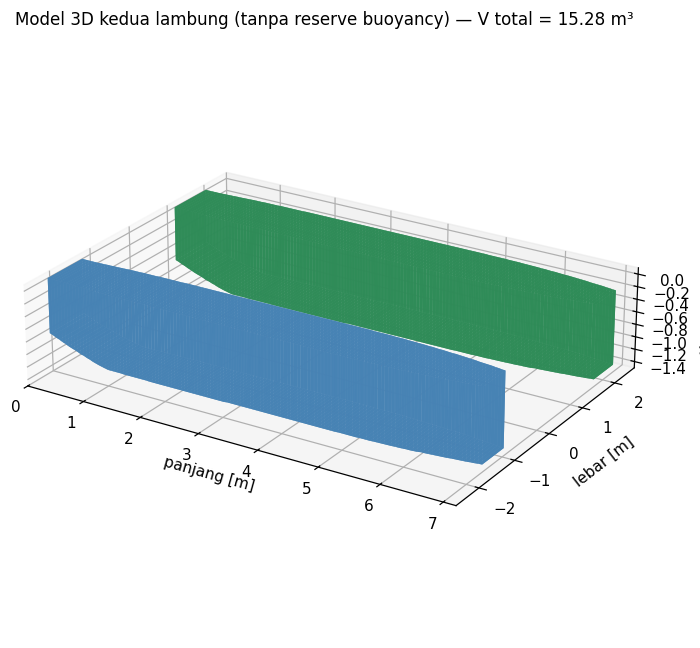

In [15]:
# ===== 9. Visual 3D kedua lambung (bagian yang dihitung) =====
Xm = (xs - X_A) * cm / 100; Wm = w1 * cm / 100; Dm = d * cm / 100
sep = (CY2 - CY1) / S * cm / 100
def hull_faces(yc):
    f = []
    for i in range(len(Xm) - 1):
        x0, x1 = Xm[i], Xm[i + 1]
        f.append([(x0, yc - Wm[i]/2, 0), (x1, yc - Wm[i+1]/2, 0), (x1, yc - Wm[i+1]/2, -Dm[i+1]), (x0, yc - Wm[i]/2, -Dm[i])])   # sisi kiri
        f.append([(x0, yc + Wm[i]/2, 0), (x1, yc + Wm[i+1]/2, 0), (x1, yc + Wm[i+1]/2, -Dm[i+1]), (x0, yc + Wm[i]/2, -Dm[i])])   # sisi kanan
        f.append([(x0, yc - Wm[i]/2, -Dm[i]), (x1, yc - Wm[i+1]/2, -Dm[i+1]), (x1, yc + Wm[i+1]/2, -Dm[i+1]), (x0, yc + Wm[i]/2, -Dm[i])])  # dasar
        f.append([(x0, yc - Wm[i]/2, 0), (x1, yc - Wm[i+1]/2, 0), (x1, yc + Wm[i+1]/2, 0), (x0, yc + Wm[i]/2, 0)])  # geladak
    for j in (0, -1):   # penutup ujung
        f.append([(Xm[j], yc - Wm[j]/2, 0), (Xm[j], yc + Wm[j]/2, 0), (Xm[j], yc + Wm[j]/2, -Dm[j]), (Xm[j], yc - Wm[j]/2, -Dm[j])])
    return f
fig = plt.figure(figsize=(13, 6))
ax = fig.add_subplot(111, projection="3d")
for yc_, col_ in [(-sep/2, "steelblue"), (sep/2, "seagreen")]:
    ax.add_collection3d(Poly3DCollection(hull_faces(yc_), facecolor=col_, edgecolor="none", alpha=.9))
ax.set_xlim(Xm[0], Xm[-1]); ax.set_ylim(-sep/2 - 1, sep/2 + 1); ax.set_zlim(-1.5, 0.1)
ax.set_box_aspect((Xm[-1]-Xm[0], sep + 2, 1.6)); ax.view_init(24, -58)
ax.set_xlabel("panjang [m]"); ax.set_ylabel("lebar [m]"); ax.set_zlabel("tinggi [m]")
ax.set_title(f"Model 3D kedua lambung (tanpa reserve buoyancy) — V total = {Vt:.2f} m³", fontsize=11)
plt.tight_layout(); plt.show()

## 8. Interpretasi hasil

**Jawaban:** volume tiap lambung ≈ **7,64 m³ (≈ 7.640 liter)**, sehingga **volume kedua lambung ≈ 15,28 m³ (≈ 15.280 liter)** (Simpson, 1 kotak = 45 cm).

**Penjelasan**
- **Ketiga metode sepakat** (Trapesium 7,631 · Simpson 7,642 · Spline 7,641 m³ per lambung dengan h = 1 kotak), selisih sekitar 0,15 %. Itu tanda bahwa diskretisasi sudah cukup rapat dan hasilnya stabil. Simpson dipakai sebagai jawaban utama karena galatnya $O(h^4)$ dibanding $O(h^2)$ pada Trapesium.
- **Bentuk lambung hampir balok.** Luas penampang naik cepat di dekat buritan (dasar melengkung naik), nyaris konstan ≈ 1,14 m² di bagian tengah, lalu mengecil di haluan karena lambung meruncing. Koefisien prismatik ≈ 0,93, artinya volume lambung ≈ 93 % balok pembatasnya. Mayoritas volume ada di bagian tengah yang lurus.
- **Makna fisik:** jika kedua lambung terbenam penuh di air laut, gaya apung maksimumnya ≈ 15,7 ton. Ini batas atas, bukan sarat sebenarnya; kapal mengapung pada sarat saat berat total = gaya apung, dan *reserve buoyancy* yang tidak dihitung menambah cadangan apung di atasnya.
- **Skala sangat menentukan:** volume ∝ (skala)³. Selisih skala 45 → 43 cm saja mengubah total dari 15,28 menjadi 13,33 m³ (−13 %). Pada render PDF yang kuunduh, 1 kotak ≈ 4,3 pola dash (bukan tepat 4,5). Jadi pastikan angka 45 cm sesuai penjelasan dosen; cukup ubah `CELL_CM` di sel 0.

**Sumber galat (batasan)**
1. Digitalisasi piksel: ±1 piksel ≈ 0,6 cm → sekitar ±0,5 % pada volume. Karena itu selisih pada h < 0,5 kotak di tabel konvergensi sudah berupa *noise* piksel, bukan galat metode.
2. Potongan dianggap persegi panjang sempurna (sesuai soal), tebal dinding fiberglass tidak dikurangkan.
3. Batas hitung diambil di x = 2 dan 18 kotak (garis *reserve buoyancy* pada gambar); garis buritan sedikit melengkung.
4. Dua lambung dianggap identik (selisih lebar terukur < 0,03 kotak).

**Kesimpulan:** $V_{\text{total}} \approx 15{,}3\ \text{m}^3$ (dua lambung, tanpa reserve buoyancy).